## Boston Housing Linear Regression Model

We will be using a dataset abput Boston Housing to create a linear model used to predict the price of housing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
boston_df = pd.read_csv("BostonHousing.csv")

In [6]:
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


#### Exploratory Data Analysis

In [7]:
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       501 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [10]:
boston_df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         5
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [11]:
# remove missing data observation
boston_df = boston_df.dropna()

In [12]:
boston_df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [14]:
# find correlation coefficients
corr_boston = boston_df.corr().round(2)

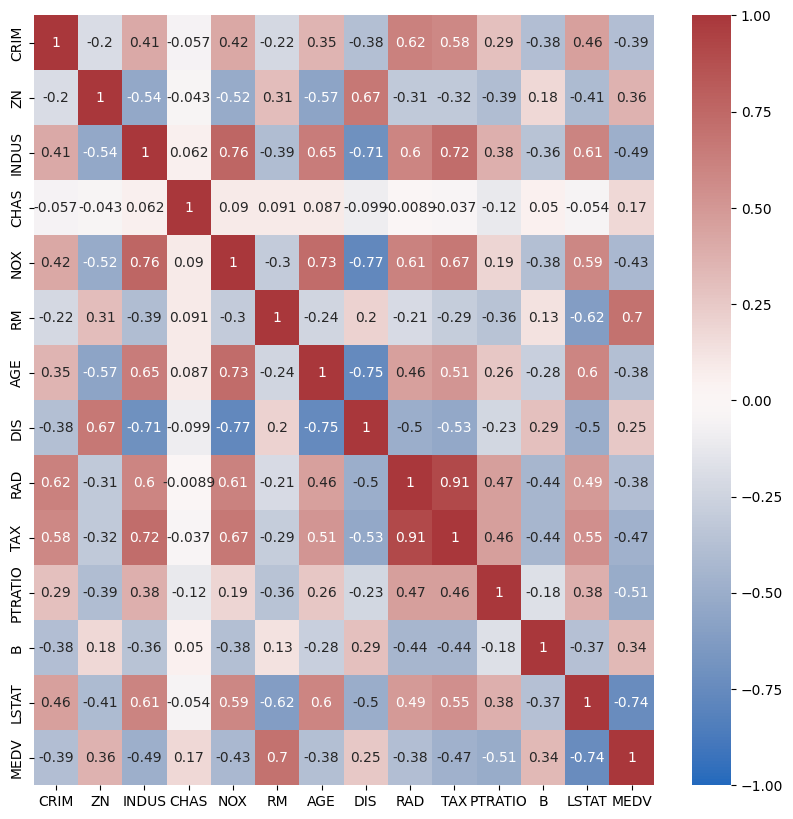

In [21]:
# make a heatmap for correlation coefficient
import seaborn as sns
plt.figure(figsize = (10, 10))
sns.heatmap(data = corr_boston, vmin = -1, vmax = 1, center = 0, annot = True, cmap = 'vlag')
plt.show()

In [22]:
abs(corr_boston.MEDV) > 0.5

CRIM       False
ZN         False
INDUS      False
CHAS       False
NOX        False
RM          True
AGE        False
DIS        False
RAD        False
TAX        False
PTRATIO     True
B          False
LSTAT       True
MEDV        True
Name: MEDV, dtype: bool

In [27]:
print(boston_df.corr().abs().nlargest(3, 'MEDV').index)

Index(['MEDV', 'LSTAT', 'RM'], dtype='object')


The top predictive variables to predict `MEDV` are `LSTAT` and `RM` which are the percentage of lower status and number of rooms respectively.

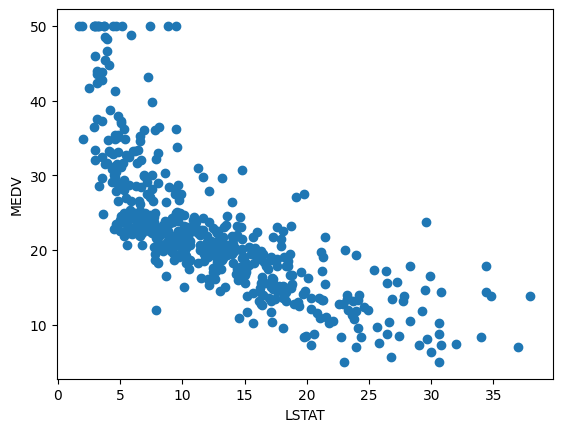

In [29]:
# visualize variables as scatterplot
plt.scatter(x = boston_df['LSTAT'], y = boston_df['MEDV'])
plt.xlabel('LSTAT')
plt.ylabel('MEDV')
plt.show()

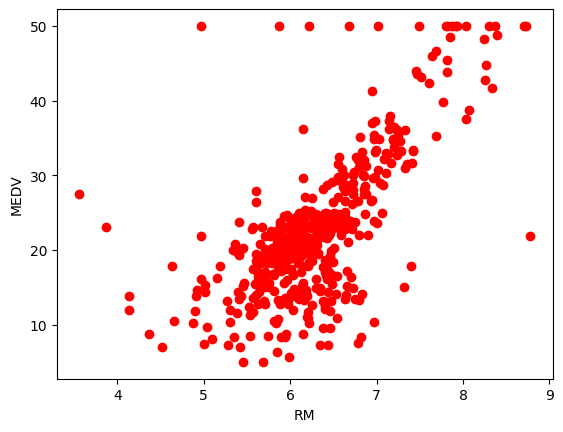

In [32]:
plt.scatter(x = boston_df['RM'], y = boston_df['MEDV'], marker = 'o', c = 'Red')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.show() 

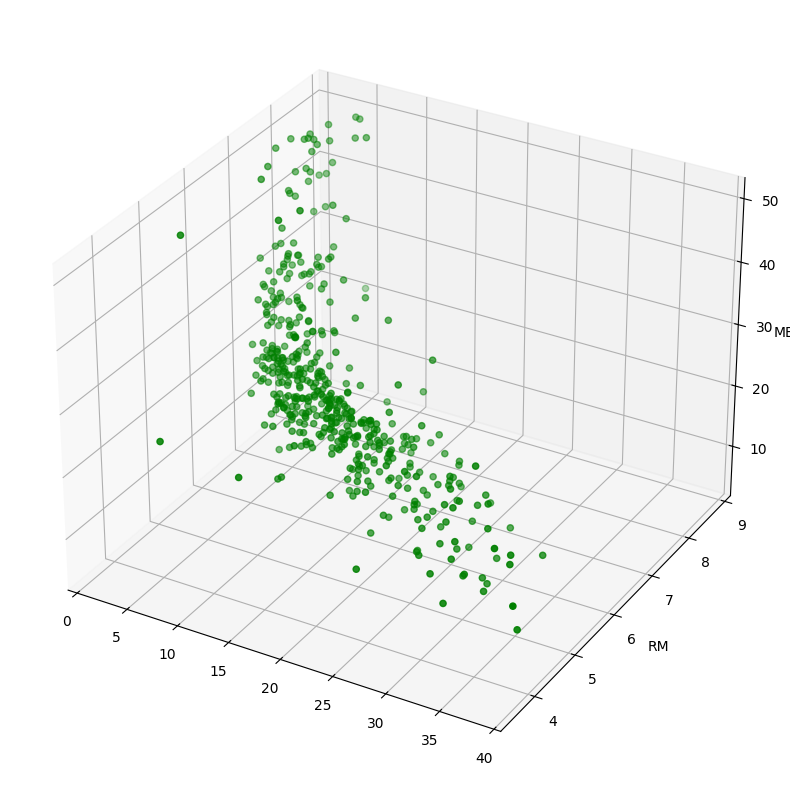

In [38]:
# Make a 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(boston_df['LSTAT'], boston_df['RM'], boston_df['MEDV'], c = 'green')

ax.set_label('LSTAT')
ax.set_ylabel('RM')
ax.set_zlabel('MEDV')
plt.show()

## Train the Model

In [40]:
# define the features
X = pd.DataFrame(np.c_[boston_df['LSTAT'], boston_df['RM']], columns = ['LSTAT', 'RM'])
print(X.head())

   LSTAT     RM
0   4.98  6.575
1   9.14  6.421
2   4.03  7.185
3   2.94  6.998
4   5.33  7.147
